# Ball Detection & Tracking — Cricket Ball Dataset (TrackNetV2 Architecture)

Pipeline for training a TrackNetV2-style heatmap detector on the **cricket-synth** dataset (synthetic cricket delivery clips with per-frame ball position labels). This replaces the earlier TrackNetV2/shuttlecock exploration — that dataset was only used to validate the pipeline before switching to our own cricket data.

Import Libraries

In [15]:
import json
import os
import random

import cv2
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt


Setup Data Paths

In [16]:
CRICKET_SYNTH_ROOT = r"D:\Git-Repos\MAGNUS\Ball-Tracking\cricket-synth\out"
CLIPS_DIR = os.path.join(CRICKET_SYNTH_ROOT, "clips")
LABELS_DIR = os.path.join(CRICKET_SYNTH_ROOT, "labels")

if not os.path.isdir(CRICKET_SYNTH_ROOT):
    raise FileNotFoundError(
        f"cricket-synth dataset not found at '{CRICKET_SYNTH_ROOT}'. "
        "Update CRICKET_SYNTH_ROOT to point at your local copy of the dataset."
    )

print(f"Using cricket-synth dataset: {CRICKET_SYNTH_ROOT}")
print(f"Clips: {len(os.listdir(CLIPS_DIR))}, Label files: {len(os.listdir(LABELS_DIR))}")


Using cricket-synth dataset: D:\Git-Repos\MAGNUS\Ball-Tracking\cricket-synth\out
Clips: 1197, Label files: 1192


Inspect Labels

cricket-synth stores per-frame ball position in JSON (one file per clip), unlike TrackNetV2's per-clip CSV (Visibility/X/Y) format.

In [17]:
sample_label_file = sorted(f for f in os.listdir(LABELS_DIR) if f.endswith(".json"))[0]
with open(os.path.join(LABELS_DIR, sample_label_file)) as f:
    sample_meta = json.load(f)

print(f"Label file: {sample_label_file}")
print(f"Frame pattern: {sample_meta['frame_pattern']}")
print(f"Frames in clip: {len(sample_meta['frames'])}")
sample_meta["frames"][:3]


Label file: batch100_000000.json
Frame pattern: f_%04d.jpg
Frames in clip: 37


[{'ball_in_scene': False,
  'visible': False,
  'on_screen': False,
  'occluded': False,
  'occluded_by': None,
  'world_m': None,
  'centre_px': None,
  'bbox_px': None,
  'radius_px': None,
  'depth_m': None,
  'streak_px': None,
  't_s': -0.2,
  'frame': 1},
 {'ball_in_scene': False,
  'visible': False,
  'on_screen': False,
  'occluded': False,
  'occluded_by': None,
  'world_m': None,
  'centre_px': None,
  'bbox_px': None,
  'radius_px': None,
  'depth_m': None,
  'streak_px': None,
  't_s': -0.166667,
  'frame': 2},
 {'ball_in_scene': False,
  'visible': False,
  'on_screen': False,
  'occluded': False,
  'occluded_by': None,
  'world_m': None,
  'centre_px': None,
  'bbox_px': None,
  'radius_px': None,
  'depth_m': None,
  'streak_px': None,
  't_s': -0.133333,
  'frame': 3}]

Inspect a Frame

In [18]:
sample_clip_id = sample_label_file[:-5]
sample_frame_path = os.path.join(
    CLIPS_DIR, sample_clip_id,
    sample_meta["frame_pattern"] % sample_meta["frames"][0]["frame"],
)
sample_image = cv2.imread(sample_frame_path)
height, width = sample_image.shape[:2]
print(f"Resolution: {width} x {height}")


Resolution: 2560 x 1440


Build Sliding-Window Frame Triplets

In [19]:
WINDOW_SIZE = 3


def build_samples_cricket_synth(clips_dir=CLIPS_DIR, labels_dir=LABELS_DIR):
    samples = []
    n_clips_used = 0
    n_clips_skipped = 0

    for label_file in sorted(os.listdir(labels_dir)):
        if not label_file.endswith(".json"):
            continue
        clip_id = label_file[:-5]
        clip_dir = os.path.join(clips_dir, clip_id)
        if not os.path.isdir(clip_dir):
            n_clips_skipped += 1
            continue

        with open(os.path.join(labels_dir, label_file)) as f:
            meta = json.load(f)

        frame_pattern = meta["frame_pattern"]

        frame_paths = []
        frame_labels = []
        ok = True
        for entry in meta["frames"]:
            frame_path = os.path.join(clip_dir, frame_pattern % entry["frame"])
            if not os.path.exists(frame_path):
                ok = False
                break
            visible = bool(entry.get("visible")) and entry.get("centre_px") is not None
            if visible:
                # centre_px is an absolute top-left-origin pixel coordinate --
                # verified against all 45,733 visible=true frames in the
                # dataset, it lands within [0,width]x[0,height] 100% of the
                # time used directly (vs. ~20% if camera.intrinsics.cx/cy is
                # added to it, which was tried and discarded).
                x, y = entry["centre_px"]
            else:
                x, y = 0.0, 0.0
            frame_paths.append(frame_path)
            frame_labels.append((1.0 if visible else 0.0, x, y))

        if not ok or len(frame_paths) < WINDOW_SIZE:
            n_clips_skipped += 1
            continue

        for i in range(len(frame_paths) - WINDOW_SIZE + 1):
            samples.append((
                frame_paths[i], frame_paths[i + 1], frame_paths[i + 2],
                frame_labels[i], frame_labels[i + 1], frame_labels[i + 2],
            ))
        n_clips_used += 1

    print(f"cricket-synth: {n_clips_used} clips used, {n_clips_skipped} skipped (missing frames/dir)")
    return samples


samples = build_samples_cricket_synth()
print(f"Built {len(samples)} sliding-window triplets")


cricket-synth: 1192 clips used, 0 skipped (missing frames/dir)
Built 72007 sliding-window triplets


TrackNetDataset — Loads & Resizes Frame Triplets

In [20]:
class TrackNetDataset(torch.utils.data.Dataset):
    def __init__(self, samples, resize_to=(512, 288)):
        self.samples = samples
        self.resize_to = resize_to

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_path_1, frame_path_2, frame_path_3, label_1, label_2, label_3 = self.samples[idx]
        new_w, new_h = self.resize_to
        images = []
        labels = []
        for frame_path, label in zip((frame_path_1, frame_path_2, frame_path_3), (label_1, label_2, label_3)):
            image = cv2.imread(frame_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            orig_h, orig_w = image.shape[:2]
            image = cv2.resize(image, self.resize_to, interpolation=cv2.INTER_AREA)
            image = image.astype(np.float32) / 255.0
            images.append(image.transpose(2, 0, 1))

            visibility, x, y = label
            scale_x = new_w / orig_w
            scale_y = new_h / orig_h
            labels.append((visibility, x * scale_x, y * scale_y))

        images = np.concatenate(images, axis=0)
        labels = np.array(labels, dtype=np.float32)
        return torch.from_numpy(images), torch.from_numpy(labels)


dataset = TrackNetDataset(samples)
images, labels = dataset[0]
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")


Images shape: torch.Size([9, 288, 512])
Labels shape: torch.Size([3, 3])


Visualize Sample Frames & Ball Position

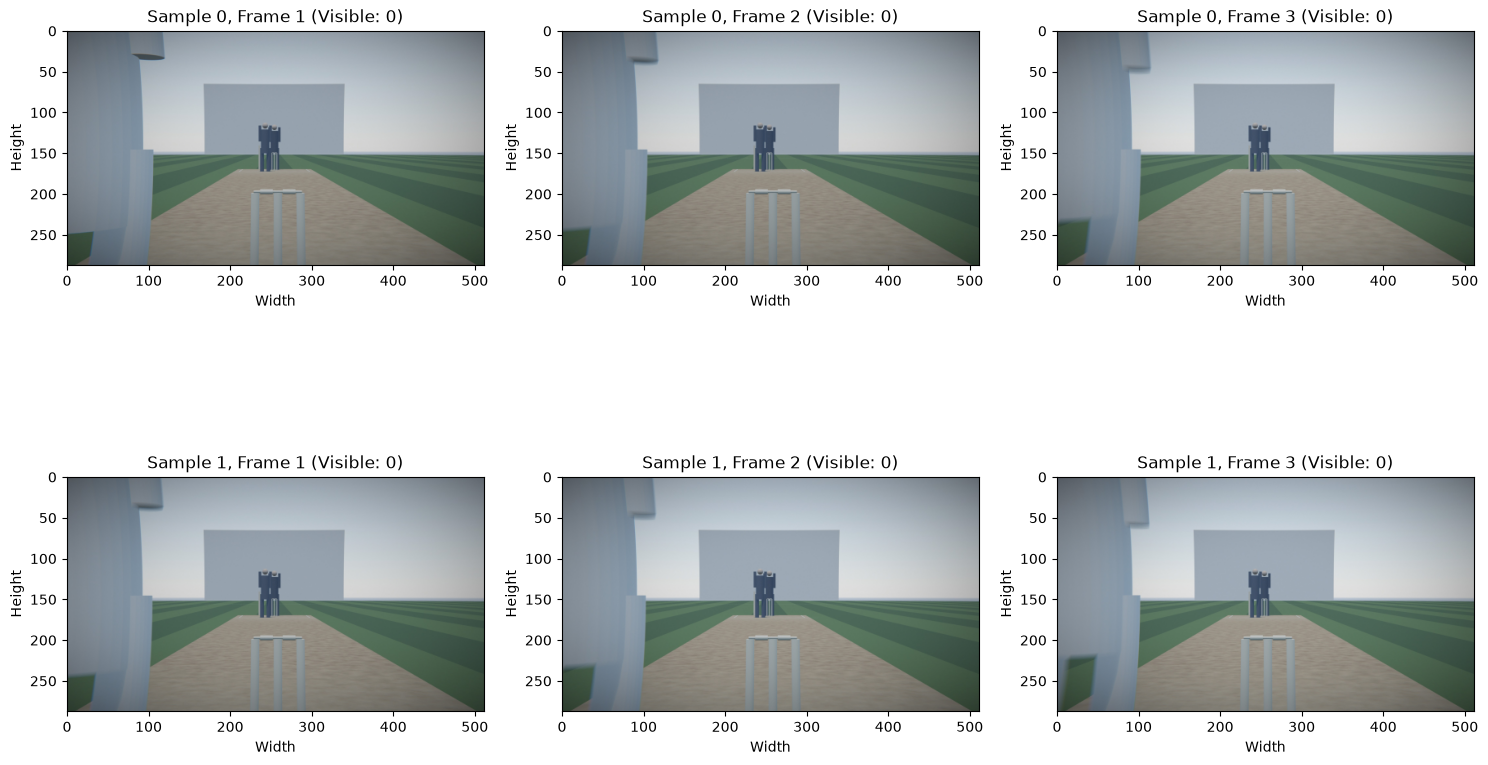

In [21]:
import math

cols = 3
num_samples_to_fetch = 2
total_frames_to_plot = num_samples_to_fetch * 3
rows = math.ceil(total_frames_to_plot / cols)
plt.figure(figsize=(cols * 5, rows * 5))

frame_counter = 0
for sample_idx in range(num_samples_to_fetch):
    images_from_sample, labels_from_sample = dataset[sample_idx]

    for i in range(3):
        img_to_show = images_from_sample[i * 3:(i * 3) + 3].permute(1, 2, 0).numpy()
        visibility, x, y = labels_from_sample[i].tolist()

        plt.subplot(rows, cols, frame_counter + 1)
        plt.imshow(img_to_show)
        plt.title(f"Sample {sample_idx}, Frame {i + 1} (Visible: {int(visibility)})")
        plt.xlabel("Width")
        plt.ylabel("Height")

        if visibility == 1:
            plt.scatter(x, y, color="red", marker="o", s=100, edgecolors="white",
                        linewidth=1, label=f"Ball position ({int(x)}, {int(y)})")
            plt.legend(loc="upper right")

        frame_counter += 1

plt.tight_layout()
plt.show()


Generate Gaussian Heatmaps for Ball Position

In [22]:
HEATMAP_SIGMA = 5


def generate_heatmap(x, y, visibility, H, W, sigma=HEATMAP_SIGMA):
    if not visibility:
        return np.zeros((H, W), dtype=np.float32)

    cols, rows = np.meshgrid(np.arange(W), np.arange(H))
    heatmap = np.exp(-((cols - x) ** 2 + (rows - y) ** 2) / (2 * sigma ** 2))
    return heatmap.astype(np.float32)


Heatmap Target Wrapper — pairs each triplet's images with its 3-channel Gaussian heatmap target

In [23]:
class TrackNetHeatmapDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
        self.W, self.H = base_dataset.resize_to

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        images, labels = self.base_dataset[idx]
        heatmaps = np.stack([
            generate_heatmap(x=labels[i, 1].item(), y=labels[i, 2].item(),
                              visibility=labels[i, 0].item(), H=self.H, W=self.W)
            for i in range(labels.shape[0])
        ], axis=0)
        return images.float(), torch.from_numpy(heatmaps)


heatmap_dataset = TrackNetHeatmapDataset(dataset)
demo_images, demo_heatmaps = heatmap_dataset[0]
print(f"Images shape: {demo_images.shape}, Heatmaps shape: {demo_heatmaps.shape}")


Images shape: torch.Size([9, 288, 512]), Heatmaps shape: torch.Size([3, 288, 512])


VGG-Style Encoder-Decoder (TrackNetV2)

In [24]:
class TrackNetV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1_conv = nn.Sequential(
            nn.Conv2d(9, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2, 2)
        self.enc2_conv = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2, 2)
        self.enc3_conv = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.pool3 = nn.MaxPool2d(2, 2)
        self.enc4_conv = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
        )
        self.pool4 = nn.MaxPool2d(2, 2)

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1_conv = nn.Sequential(
            nn.Conv2d(768, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2_conv = nn.Sequential(
            nn.Conv2d(384, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3_conv = nn.Sequential(
            nn.Conv2d(192, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.up4 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.final_conv = nn.Conv2d(32, 3, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1_conv(x)
        p1 = self.pool1(e1)
        e2 = self.enc2_conv(p1)
        p2 = self.pool2(e2)
        e3 = self.enc3_conv(p2)
        p3 = self.pool3(e3)
        e4 = self.enc4_conv(p3)
        p4 = self.pool4(e4)

        d1 = self.up1(p4)
        d1 = torch.cat([d1, e4], dim=1)
        d1 = self.dec1_conv(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e3], dim=1)
        d2 = self.dec2_conv(d2)

        d3 = self.up3(d2)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.dec3_conv(d3)

        d4 = self.up4(d3)
        out = self.final_conv(d4)
        return out


## Train/Val/Test Split by Clip (70/15/15)

Splits by *clip* (not by frame) so no clip's frames leak across splits. Test is carved out **first**, before val, and is never touched by the training loop or by checkpoint selection below -- it stays a genuinely held-out set for the quantitative evaluation cell near the end of this notebook. The split is written to `Checkpoints/cricket_synth_70-15-15_split.json` the first time it runs, so it's auditable and stable across kernel restarts (same seed regenerates the same split either way).

In [25]:
def get_clip_id(sample):
    return os.path.normpath(os.path.dirname(sample[0]))


clip_ids = [get_clip_id(s) for s in samples]
unique_clips = sorted(set(clip_ids))
print(f"Total samples: {len(samples)}, unique clips: {len(unique_clips)}")

SPLIT_SEED = 42
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15

# Test is carved out first -- it never becomes part of train_indices or
# val_indices below, so nothing (gradients or checkpoint selection) ever
# sees it. That's what makes it a genuine held-out test set.
split_rng = random.Random(SPLIT_SEED)
shuffled_clips = unique_clips[:]
split_rng.shuffle(shuffled_clips)

n_test_clips = max(1, int(len(shuffled_clips) * TEST_FRACTION))
n_val_clips = max(1, int(len(shuffled_clips) * VAL_FRACTION))
test_clips = set(shuffled_clips[:n_test_clips])
val_clips = set(shuffled_clips[n_test_clips:n_test_clips + n_val_clips])
train_clips = set(shuffled_clips[n_test_clips + n_val_clips:])

train_indices = [i for i, cid in enumerate(clip_ids) if cid in train_clips]
val_indices = [i for i, cid in enumerate(clip_ids) if cid in val_clips]
test_indices = [i for i, cid in enumerate(clip_ids) if cid in test_clips]
rng = random.Random(42)
rng.shuffle(train_indices)
rng.shuffle(val_indices)

print(f"Train samples: {len(train_indices)} from {len(train_clips)} clips (70%)")
print(f"Val samples:   {len(val_indices)} from {len(val_clips)} clips (15%, checkpoint selection)")
print(f"Test samples:  {len(test_indices)} from {len(test_clips)} clips (15%, held out until final eval)")

SPLIT_MANIFEST_PATH = "Checkpoints/cricket_synth_70-15-15_split.json"
os.makedirs("Checkpoints", exist_ok=True)
if not os.path.exists(SPLIT_MANIFEST_PATH):
    with open(SPLIT_MANIFEST_PATH, "w") as f:
        json.dump({
            "train_clips": sorted(train_clips),
            "val_clips": sorted(val_clips),
            "test_clips": sorted(test_clips),
        }, f, indent=2)
    print(f"Wrote split manifest -> {SPLIT_MANIFEST_PATH}")
else:
    print(f"Split manifest already exists at {SPLIT_MANIFEST_PATH} (not overwritten)")

# local RTX 2050 has 4GB VRAM -- batch_size=4 + AMP fits comfortably.
BATCH_SIZE = 4
train_subset_full = torch.utils.data.Subset(heatmap_dataset, train_indices)
val_subset_full = torch.utils.data.Subset(heatmap_dataset, val_indices)
test_subset_full = torch.utils.data.Subset(heatmap_dataset, test_indices)

# num_workers=0: on Windows, DataLoader workers use spawn multiprocessing,
# which can't pickle classes (TrackNetHeatmapDataset) defined live inside a
# Jupyter kernel's __main__ -- workers crash immediately with an
# AttributeError. Single-process loading is plenty fast here anyway: the
# GPU compute step is the bottleneck, not disk I/O.
full_train_loader = torch.utils.data.DataLoader(
    train_subset_full, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True,
)
full_val_loader = torch.utils.data.DataLoader(
    val_subset_full, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True,
)
full_test_loader = torch.utils.data.DataLoader(
    test_subset_full, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True,
)


Total samples: 72007, unique clips: 1192
Train samples: 49594 from 836 clips (70%)
Val samples:   11007 from 178 clips (15%, checkpoint selection)
Test samples:  11406 from 178 clips (15%, held out until final eval)
Split manifest already exists at Checkpoints/cricket_synth_70-15-15_split.json (not overwritten)


Model, Weighted BCE Loss, Optimizer -- and resumable checkpoint loading. If `Checkpoints/cricket_synth_70-15-15_checkpoint.pt` already exists (e.g. the kernel restarted mid-run), this picks up exactly where it left off instead of starting over.

In [26]:
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(DEVICE)}")

CHECKPOINT_PATH = "Checkpoints/cricket_synth_70-15-15_checkpoint.pt"
BEST_MODEL_PATH = "Checkpoints/cricket_synth_70-15-15_best_model.pt"
LOG_PATH = "Checkpoints/cricket_synth_70-15-15_training_log.txt"


def log(msg):
    line = f"[{time.strftime('%H:%M:%S')}] {msg}"
    print(line, flush=True)
    with open(LOG_PATH, "a") as f:
        f.write(line + "\n")


model = TrackNetV2().to(DEVICE)

# Gaussian blobs (sigma=5) cover under ~0.5% of the 288x512 frame's pixels,
# so pos_weight is raised substantially -- otherwise ball pixels are
# drowned out by background in the loss.
POS_WEIGHT = 200.0
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=DEVICE))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

# Mixed precision keeps peak VRAM under the RTX 2050's 4GB budget.
USE_AMP = DEVICE.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

start_epoch = 0
step_in_epoch = 0
history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state = None
patience_counter = 0
running_loss = 0.0
running_count = 0

if os.path.exists(CHECKPOINT_PATH):
    log(f"Found checkpoint at {CHECKPOINT_PATH}, resuming...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    scaler.load_state_dict(ckpt["scaler_state"])
    start_epoch = ckpt["epoch"]
    step_in_epoch = ckpt["step_in_epoch"]
    history = ckpt["history"]
    best_val_loss = ckpt["best_val_loss"]
    best_state = ckpt["best_state"]
    patience_counter = ckpt["patience_counter"]
    running_loss = ckpt["running_loss"]
    running_count = ckpt["running_count"]
    log(f"Resumed at epoch {start_epoch + 1}, step {step_in_epoch}, "
        f"running_train_loss={running_loss / max(running_count, 1):.4f}")
else:
    log("No checkpoint found -- starting fresh from random init on the 70/15/15 split.")

print(f"AMP enabled: {USE_AMP}")


Device: cuda
GPU: NVIDIA GeForce RTX 2050


[20:02:48] Found checkpoint at Checkpoints/cricket_synth_70-15-15_checkpoint.pt, resuming...
[20:02:48] Resumed at epoch 1, step 7400, running_train_loss=0.0701
AMP enabled: True


## Training Loop -- 70/15/15 split, checkpointed, resumable

This is the real training run, driven entirely from this notebook (the standalone `train_cricket_synth.py` script does the same thing for background/unattended runs, but isn't required). Progress is checkpointed to `Checkpoints/cricket_synth_70-15-15_checkpoint.pt` every 200 steps and at the end of every epoch, so interrupting the kernel and re-running this cell picks up from the last checkpoint rather than restarting. 20 epochs, early stopping after 3 epochs with no val_loss improvement.

In [ ]:
import copy

NUM_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 3
CHECKPOINT_EVERY = 200
steps_per_epoch = len(full_train_loader)


def save_checkpoint(epoch, step):
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "epoch": epoch,
        "step_in_epoch": step,
        "history": history,
        "best_val_loss": best_val_loss,
        "best_state": best_state,
        "patience_counter": patience_counter,
        "running_loss": running_loss,
        "running_count": running_count,
    }, CHECKPOINT_PATH)


for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()
    model.train()
    resume_step = step_in_epoch if epoch == start_epoch else 0
    if epoch != start_epoch:
        running_loss = 0.0
        running_count = 0

    # Seeded per-epoch order, so a resume jumps straight to resume_step
    # instead of loading (and discarding) every batch before it.
    epoch_gen = torch.Generator().manual_seed(SPLIT_SEED + epoch)
    epoch_order = torch.randperm(len(train_subset_full), generator=epoch_gen).tolist()
    epoch_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(train_subset_full, epoch_order[resume_step * BATCH_SIZE:]),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True,
    )

    for step, (images, targets) in enumerate(epoch_loader, start=resume_step):

        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        running_count += images.size(0)

        current_step = step + 1
        if current_step % CHECKPOINT_EVERY == 0:
            save_checkpoint(epoch, current_step)
            log(f"  epoch {epoch + 1} step {current_step}/{steps_per_epoch} "
                f"running_train_loss={running_loss / running_count:.4f} (checkpoint saved)")

    train_loss = running_loss / running_count

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, targets in full_val_loader:
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, targets)
            val_running_loss += loss.item() * images.size(0)
    val_loss = val_running_loss / len(val_subset_full)

    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    elapsed_min = (time.time() - epoch_start) / 60
    current_lr = optimizer.param_groups[0]["lr"]
    log(f"epoch {epoch + 1}/{NUM_EPOCHS} done - train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  "
        f"lr: {current_lr:.2e}  ({elapsed_min:.1f} min)")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(best_state, BEST_MODEL_PATH)
        log(f"New best model saved (val_loss={best_val_loss:.4f}) -> {BEST_MODEL_PATH}")
    else:
        patience_counter += 1
        if patience_counter > EARLY_STOPPING_PATIENCE:
            log(f"Early stopping after {epoch + 1} epochs -- no val_loss improvement for "
                f"{EARLY_STOPPING_PATIENCE} consecutive epochs.")
            save_checkpoint(epoch + 1, 0)
            break

    step_in_epoch = 0
    save_checkpoint(epoch + 1, 0)

if best_state is not None:
    model.load_state_dict(best_state)
    log(f"Restored best model weights (val_loss={best_val_loss:.4f}).")

log("Training complete.")


[20:04:44]   epoch 1 step 7600/12399 running_train_loss=0.0691 (checkpoint saved)


Loss Curve & Predictions on Held-Out Clips

In [ ]:
if history["train_loss"]:
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("BCEWithLogitsLoss")
    plt.legend()
    plt.title("Train vs held-out-clip val loss")
    plt.show()
else:
    print("No training history to plot -- model was loaded from an existing checkpoint, not trained this run.")

# Visualize predictions on held-out validation clips (never seen during training)
model.eval()
n_show = 8
show_indices = random.Random(123).sample(val_indices, min(n_show, len(val_indices)))
frame_idx = 1

fig, axes = plt.subplots(len(show_indices), 2, figsize=(6, len(show_indices) * 3))
with torch.no_grad():
    for row, idx in enumerate(show_indices):
        images, targets = heatmap_dataset[idx]
        images = images.unsqueeze(0).to(DEVICE)
        logits = model(images)
        preds = torch.sigmoid(logits)

        pred_heatmap = preds[0, frame_idx].cpu().numpy()
        target_heatmap = targets[frame_idx].numpy()

        axes[row, 0].imshow(pred_heatmap, cmap="hot", vmin=0, vmax=1)
        axes[row, 0].set_title(f"val idx={idx} Pred (max={pred_heatmap.max():.3f})", fontsize=9)
        axes[row, 0].axis("off")
        axes[row, 1].imshow(target_heatmap, cmap="hot", vmin=0, vmax=1)
        axes[row, 1].set_title(f"val idx={idx} GT (max={target_heatmap.max():.3f})", fontsize=9)
        axes[row, 1].axis("off")

plt.tight_layout()
plt.show()


## Sanity-Check Predictions on Held-Out Val Clips

Loads `Checkpoints/cricket_synth_70-15-15_best_model.pt` (the training run above) and eyeballs it against a handful of held-out validation clips using the 70/15/15 split from earlier in this notebook. This is a quick qualitative look, not a metric -- for the real quantitative number, see the full test-set evaluation cell further down, which uses `test_indices` (never touched above) instead of `val_indices`. Also saves a preview grid image to `Output/cricket_synth_predictions_preview.png`.

In [ ]:
BEST_MODEL_PATH = "Checkpoints/cricket_synth_70-15-15_best_model.pt"
PREDICTIONS_PREVIEW_PATH = "Output/cricket_synth_predictions_preview.png"
DETECTION_THRESHOLD = 0.5

if os.path.exists(BEST_MODEL_PATH):
    inspect_model = TrackNetV2().to(DEVICE)
    inspect_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=True))
    inspect_model.eval()

    pick_rng = random.Random(7)
    chosen = pick_rng.sample(val_indices, min(6, len(val_indices)))

    fig, axes = plt.subplots(len(chosen), 3, figsize=(12, 4 * len(chosen)))
    if len(chosen) == 1:
        axes = axes[np.newaxis, :]
    errors = []
    with torch.no_grad():
        for row, idx in enumerate(chosen):
            raw_images, raw_labels = dataset[idx]
            heatmap_images, _ = heatmap_dataset[idx]
            probs = torch.sigmoid(inspect_model(heatmap_images.unsqueeze(0).to(DEVICE)))[0].cpu().numpy()
            images_np = raw_images.numpy()

            for frame_idx in range(3):
                ax = axes[row, frame_idx]
                frame = images_np[frame_idx * 3:(frame_idx + 1) * 3].transpose(1, 2, 0)
                ax.imshow(np.clip(frame, 0, 1))

                visibility, gt_x, gt_y = raw_labels[frame_idx].tolist()
                prob_map = probs[frame_idx]
                pmax = prob_map.max()

                if visibility:
                    ax.scatter([gt_x], [gt_y], c="lime", marker="o", s=80,
                               facecolors="none", linewidths=2, label="GT")

                title = f"frame {frame_idx} "
                if pmax > DETECTION_THRESHOLD:
                    py, px = np.unravel_index(np.argmax(prob_map), prob_map.shape)
                    ax.scatter([px], [py], c="red", marker="x", s=80, linewidths=2, label="pred")
                    title += f"(conf={pmax:.2f})"
                    if visibility:
                        dist = ((px - gt_x) ** 2 + (py - gt_y) ** 2) ** 0.5
                        title += f" err={dist:.1f}px"
                        errors.append(dist)
                else:
                    title += f"(no det, max={pmax:.2f})"
                    if visibility:
                        title += " [MISS]"

                ax.set_title(title, fontsize=9)
                ax.axis("off")
                if row == 0 and frame_idx == 0:
                    ax.legend(loc="upper right", fontsize=7)

    plt.tight_layout()
    os.makedirs(os.path.dirname(PREDICTIONS_PREVIEW_PATH), exist_ok=True)
    plt.savefig(PREDICTIONS_PREVIEW_PATH, dpi=110)
    print(f"Saved preview to {PREDICTIONS_PREVIEW_PATH}")
    plt.show()

    if errors:
        errors = np.array(errors)
        print(f"Detections with GT visible: {len(errors)}")
        print(f"Mean pixel error: {errors.mean():.2f}  Median: {np.median(errors):.2f}  Max: {errors.max():.2f}")
    else:
        print("No confident detections on visible-ball frames in this sample.")
else:
    print(f"No checkpoint found at {BEST_MODEL_PATH} yet -- run the training loop above first.")


## Quantitative Test-Set Evaluation

The real number: runs `inspect_model` over **every** triplet in `test_indices` -- the 15% of clips carved out first in the split cell and never touched by training or by checkpoint selection. Reports, over the full test set rather than a 6-sample eyeball: detection/miss rate and pixel-error distribution on frames where the ball is actually visible, plus the false-positive rate on frames where it isn't (the failure mode found earlier in the val preview).

In [ ]:
if "inspect_model" not in dir():
    raise RuntimeError(
        "Run the 'Sanity-Check Predictions on Held-Out Val Clips' cell above first "
        "to load inspect_model from cricket_synth_70-15-15_best_model.pt."
    )

TEST_EVAL_BATCH = 8
test_errors = []
test_total_visible = 0
test_true_positives = 0   # confident detection when the ball IS visible
test_misses = 0           # no confident detection when the ball IS visible
test_false_positives = 0  # confident detection when the ball is NOT visible
n_test_frames = 3 * len(test_indices)

inspect_model.eval()
with torch.no_grad():
    for start in range(0, len(test_indices), TEST_EVAL_BATCH):
        batch_idx = test_indices[start:start + TEST_EVAL_BATCH]
        batch_images = torch.stack([heatmap_dataset[i][0] for i in batch_idx]).to(DEVICE)
        probs = torch.sigmoid(inspect_model(batch_images)).cpu().numpy()  # (B, 3, H, W)

        for b, idx in enumerate(batch_idx):
            _, raw_labels = dataset[idx]
            for frame_idx in range(3):
                visibility, gt_x, gt_y = raw_labels[frame_idx].tolist()
                prob_map = probs[b, frame_idx]
                pmax = prob_map.max()
                detected = pmax > DETECTION_THRESHOLD

                if visibility:
                    test_total_visible += 1
                    if detected:
                        py, px = np.unravel_index(np.argmax(prob_map), prob_map.shape)
                        test_errors.append(((px - gt_x) ** 2 + (py - gt_y) ** 2) ** 0.5)
                        test_true_positives += 1
                    else:
                        test_misses += 1
                elif detected:
                    test_false_positives += 1

        done = start + len(batch_idx)
        if (start // TEST_EVAL_BATCH) % 50 == 0 or done == len(test_indices):
            print(f"  evaluated {done}/{len(test_indices)} test triplets...")

test_errors = np.array(test_errors)
n_not_visible = n_test_frames - test_total_visible

print()
print(f"Test set: {len(test_indices)} triplets from {len(test_clips)} clips, {n_test_frames} frames total "
      f"(never used for training or checkpoint selection)")
print(f"  visible-ball frames: {test_total_visible}   not-visible frames: {n_not_visible}")
print()
print(f"On visible-ball frames (localization quality, threshold={DETECTION_THRESHOLD}):")
print(f"  detected: {test_true_positives}/{test_total_visible} "
      f"({100 * test_true_positives / max(test_total_visible, 1):.1f}%)")
print(f"  missed:   {test_misses}/{test_total_visible} "
      f"({100 * test_misses / max(test_total_visible, 1):.1f}%)")
if len(test_errors):
    print(f"  pixel error (detected only) -- mean: {test_errors.mean():.2f}  "
          f"median: {np.median(test_errors):.2f}  p90: {np.percentile(test_errors, 90):.2f}  "
          f"max: {test_errors.max():.2f}")
print()
print(f"On not-visible frames (false-positive rate -- the failure mode seen in the val preview):")
print(f"  false positives: {test_false_positives}/{n_not_visible} "
      f"({100 * test_false_positives / max(n_not_visible, 1):.1f}%)")


## Test the Tracker on Real Video Footage

Runs the trained model (`inspect_model`, loaded above from `Checkpoints/cricket_synth_70-15-15_best_model.pt`) on the raw `.mp4` clips in `Dataset/test/` -- real footage with no ground-truth labels, just qualitative detection on unseen video. Frames are grouped into non-overlapping triplets (matching the WINDOW_SIZE=3 training input), each producing a per-frame ball heatmap; the argmax pixel above `DETECTION_THRESHOLD` confidence is taken as the detection and mapped back to the video's native resolution. A fading trail of recent detections is drawn on top of each frame. Annotated copies are written to `Output/tracked/`.

In [ ]:
def read_video_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    frames = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(frame)
    cap.release()
    return frames, fps


def run_tracker_on_video(video_path, output_path, model, device,
                          threshold=0.9, resize_to=(512, 288), trail_len=7,
                          min_consecutive=2, max_accel_px=None,
                          high_conf_override=0.97, max_gap_frames=10):
    frames, fps = read_video_frames(video_path)
    n = len(frames)
    print(f"{os.path.basename(video_path)}: {n} frames @ {fps:.1f} fps")
    if n == 0:
        print("  no frames read, skipping")
        return []

    orig_h, orig_w = frames[0].shape[:2]
    new_w, new_h = resize_to
    scale_x = orig_w / new_w
    scale_y = orig_h / new_h

    if max_accel_px is None:
        max_accel_px = max(15.0, 0.02 * orig_w)

    # Per-frame argmax confidence/position, computed for every frame
    # regardless of threshold so the persistence filter below has the full
    # confidence trace to work with.
    raw_conf = [0.0] * n
    raw_pos = [(0.0, 0.0)] * n

    model.eval()
    with torch.no_grad():
        for start in range(0, n, WINDOW_SIZE):
            group = frames[start:start + WINDOW_SIZE]
            pad = WINDOW_SIZE - len(group)
            if pad:
                group = group + [group[-1]] * pad

            batch = []
            for frame in group:
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                resized = cv2.resize(rgb, resize_to, interpolation=cv2.INTER_AREA)
                batch.append(resized.astype(np.float32) / 255.0)
            stacked = np.concatenate([f.transpose(2, 0, 1) for f in batch], axis=0)
            tensor = torch.from_numpy(stacked).unsqueeze(0).to(device)

            probs = torch.sigmoid(model(tensor))[0].cpu().numpy()  # (3, H, W)

            n_valid = WINDOW_SIZE - pad
            for k in range(n_valid):
                prob_map = probs[k]
                conf = float(prob_map.max())
                py, px = np.unravel_index(np.argmax(prob_map), prob_map.shape)
                raw_conf[start + k] = conf
                raw_pos[start + k] = (px * scale_x, py * scale_y)

    n_raw = sum(c >= threshold for c in raw_conf)
    print(f"  raw frames above threshold={threshold}: {n_raw}/{n}")

    # Persistence filter: on real footage the ball is invisible for long
    # stretches (run-up, occlusion) during which the heatmap head still
    # fires a spurious argmax -- usually well below 0.9, but occasionally a
    # single frame spikes into the 0.9s too. What reliably tells a real
    # detection apart is that once the ball is genuinely visible, confidence
    # sits at ~0.98-1.00 and *stays* there for many consecutive frames,
    # whereas false spikes are isolated 1-2 frame blips. Drop any run of
    # above-threshold frames shorter than min_consecutive.
    above = [c >= threshold for c in raw_conf]
    persistent = above[:]
    i = 0
    while i < n:
        if above[i]:
            j = i
            while j < n and above[j]:
                j += 1
            if j - i < min_consecutive:
                for k in range(i, j):
                    persistent[k] = False
            i = j
        else:
            i += 1
    n_persistent = sum(persistent)
    print(f"  frames surviving persistence filter (min_consecutive={min_consecutive}): {n_persistent}/{n}")

    candidates = [
        (raw_pos[i][0], raw_pos[i][1], raw_conf[i]) if persistent[i] else None
        for i in range(n)
    ]

    # Trajectory-consistency gate, as a second line of defense: a surviving
    # candidate is only accepted if it lands near where constant-velocity
    # extrapolation from the last accepted point predicts the ball should
    # be. Resets after a long gap so the ball can be reacquired anywhere.
    detections = [None] * n
    last_pos = None
    last_frame = None
    velocity = None

    for i in range(n):
        cand = candidates[i]
        if cand is None:
            if last_frame is not None and i - last_frame > max_gap_frames:
                last_pos = None
                last_frame = None
                velocity = None
            continue

        x, y, conf = cand
        accept = True
        if last_pos is not None:
            dt = i - last_frame
            if dt > max_gap_frames:
                velocity = None
            if velocity is not None:
                predicted_x = last_pos[0] + velocity[0] * dt
                predicted_y = last_pos[1] + velocity[1] * dt
                deviation = ((x - predicted_x) ** 2 + (y - predicted_y) ** 2) ** 0.5
                if deviation > max_accel_px * dt and conf < high_conf_override:
                    accept = False

        if accept:
            detections[i] = (x, y, conf)
            if last_pos is not None:
                dt = i - last_frame
                velocity = ((x - last_pos[0]) / dt, (y - last_pos[1]) / dt)
            last_pos = (x, y)
            last_frame = i

    n_detected = sum(d is not None for d in detections)
    print(f"  final detections after trajectory gate: {n_detected}/{n} frames")

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (orig_w, orig_h))

    trail = []
    for i, frame in enumerate(frames):
        vis = frame.copy()
        det = detections[i]
        if det is not None:
            trail.append(det[:2])
            if len(trail) > trail_len:
                trail.pop(0)

        for j, (tx, ty) in enumerate(trail):
            alpha = (j + 1) / len(trail)
            radius = 3 + int(4 * alpha)
            color = (0, int(255 * alpha), 255)
            cv2.circle(vis, (int(tx), int(ty)), radius, color, -1)

        if det is not None:
            x, y, conf = det
            cv2.circle(vis, (int(x), int(y)), 8, (0, 0, 255), 2)
            cv2.putText(vis, f"{conf:.2f}", (int(x) + 10, int(y) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)

        writer.write(vis)
    writer.release()

    print(f"  saved annotated video to {output_path}")
    return detections


In [ ]:
if "inspect_model" not in dir():
    raise RuntimeError(
        "Run the 'Sanity-Check Predictions on Held-Out Val Clips' cell above first "
        "to load inspect_model from cricket_synth_70-15-15_best_model.pt."
    )

TEST_VIDEOS_DIR = "Dataset/test"
TRACKED_OUTPUT_DIR = "Output/tracked"

test_videos = sorted(
    f for f in os.listdir(TEST_VIDEOS_DIR)
    if f.lower().endswith((".mp4", ".mov", ".avi"))
)
print(f"Found {len(test_videos)} test video(s): {test_videos}")

all_detections = {}
for video_name in test_videos:
    video_path = os.path.join(TEST_VIDEOS_DIR, video_name)
    output_path = os.path.join(TRACKED_OUTPUT_DIR, os.path.splitext(video_name)[0] + "_tracked.mp4")
    all_detections[video_name] = run_tracker_on_video(
        video_path, output_path, inspect_model, DEVICE, threshold=0.9,
    )


In [ ]:
for video_name, detections in all_detections.items():
    n = len(detections)
    hits = [d for d in detections if d is not None]
    confs = np.array([d[2] for d in hits]) if hits else np.array([])
    print(f"{video_name}: {len(hits)}/{n} frames detected"
          + (f", mean conf={confs.mean():.2f}" if len(confs) else ""))
